In [2]:
import math
from scipy import integrate
import numpy as np
import sympy as sp

1. Вычислить приближенное значение интеграла $\int_{a}^{b} f(x)dx$, используя формулы трапеции, Симпсона, трех-восьмых, прямоугольников и Гаусса ($n=4, 5$ или $7$). Оценить остаточный член формул.

In [17]:
# ======= ПАРАМЕТРЫ =======

a = 0.4
b = 1.2
n = 12 # Число разбиений, кратное 2 и 3
gauss_ns = [4, 5, 7]

# ======= Ф-ЦИЯ - 12 ВАРИАНТ =======

x_sym = sp.symbols('x')
f_expr = sp.cos(x_sym**2) * sp.sqrt(x_sym)
f = sp.lambdify(x_sym, f_expr, 'numpy')

# ======= ВЫЧИСЛЕНИЯ =======

f_diff1 = sp.diff(f_expr, x_sym, 1)
f_diff2 = sp.diff(f_expr, x_sym, 2)
f_diff4 = sp.diff(f_expr, x_sym, 4)
f_diff8 = sp.diff(f_expr, x_sym, 8)   # ДЛЯ ГАУССА n=4
f_diff10 = sp.diff(f_expr, x_sym, 10) # ДЛЯ ГАУССА n=5
f_diff14 = sp.diff(f_expr, x_sym, 14) # ДЛЯ ГАУССА n=7

f_diff1_func = sp.lambdify(x_sym, sp.Abs(f_diff1), 'numpy')
f_diff2_func = sp.lambdify(x_sym, sp.Abs(f_diff2), 'numpy')
f_diff4_func = sp.lambdify(x_sym, sp.Abs(f_diff4), 'numpy')
f_diff8_func = sp.lambdify(x_sym, sp.Abs(f_diff8), 'numpy')
f_diff10_func = sp.lambdify(x_sym, sp.Abs(f_diff10), 'numpy')
f_diff14_func = sp.lambdify(x_sym, sp.Abs(f_diff14), 'numpy')

x_vals = np.linspace(a, b, 5000)
M1 = np.max(f_diff1_func(x_vals))
M2 = np.max(f_diff2_func(x_vals))
M4 = np.max(f_diff4_func(x_vals))
M8 = np.max(f_diff8_func(x_vals))
M10 = np.max(f_diff10_func(x_vals))
M14 = np.max(f_diff14_func(x_vals))

print(f"M1: {M1:.4f} | M2: {M2:.4f} | M4: {M4:.4f}")
print(f"M8: {M8:.4f} | M10: {M10:.4f} | M14: {M14:.4e}\n")

# ======= МЕТОД ЛЕВЫХ ПРЯМОУГОЛЬНИКОВ =======

def method_rectangle_left(f, a, b, n, M1):
    """
    Вычисляет интеграл ф-ции f на отрезке [a, b] методом прмяоугольников

    Параметры:
    f - интегрируемая ф-ция
    a, b - пределы интегрирования
    n - кол-во разбиений
    M1 - максимум 1-ой производной (число, для погрешностси)
    
    Суть метода в том, что делим оторезок [a, b] на n равных частей 
    шириной h = (a - b) / n. На каждом участке строим прямоугольник,
    высота которого равна значению ф-ции в левой точке участка.
    Складываем площадь
    """

    # Ширина одного прямоугольника 
    h = (b - a) / n
    # Сумма площадей
    total_sum = 0

    # Проходим по всем прямоугольникам от 0 до n-1
    for i in range(n):
        # Находим координату левого края текущего прмяоугольника
        # x0 = a
        # x1 = a + h
        # x2 = a + 2*h
        # ...
        x_current = a + i * h

        # Высота прямоугольника - это значение ф-ции в этой точке
        height = f(x_current)

        # Добавляем высоту в общую сумму
        total_sum += height

    # Умножаем сумму высот на ширину (h), чтобы получить площадь
    result = total_sum * h

    # Оценка погрешности
    R = ((b - a)**2 / (2 * n)) * M1

    # # Вычисляем шаг интегрирвоания h
    # h = (b - a) / n
    # x = np.linspace(a, b - h, n)
    # result = h * np.sum(f(x))
    # # Оценка погрешности
    # R = ((b - a)**2 / (2 * n)) * M1

    return result, R
    pass

# ======= МЕТОД ТРАПЕЦИЙ =======

def method_trapezoid(f, a, b, n, M2):
    """
    Вычисляет интеграл ф-ции f на отрезке [a, b] методом трапеций

    Параметры:
    f - интегрируемая ф-ция
    a, b - пределы интегрирования
    n - кол-во разбиений
    M2 - максимум 2-ой производной (число, для погрешностси)

    Вместо прямоугольников используем трапеции. Соединяем точки 
    на графике прямыми линиями, получается ломаная. Точнее прмяоугольников,
    потому что учитывает наклон ф-ции
    """

    # Ширина одной трапеции
    h = (b - a) / n
    # Сумма краев
    sum_ends = (f(a) + f(b)) / 2

    # Сумма внутренних точек, т.к. только внутренние точки 
    # повторяются дважды при расчете площади каждой трапеции
    sum_inner = 0
    for i in range(1, n):
        x_curr = a + i * h
        sum_inner += f(x_curr)

    # Общий результат
    result = h * (sum_ends + sum_inner)

    # Оценка погрешности
    R = (M2 * (b - a) * h**2) / 12




    # # Ширина одного трапеции
    # h = (b - a) / n
    # # Создаем массив усзловых точек
    # x = np.linspace(a, b, n + 1)
    # # Считаем значение узловых точек 
    # y = f(x)
    # result = h * ((y[0] + y[-1])/2 + np.sum(y[1:-1]))
    # R = ((b - a) / 12) * M2 + (h**2)

    return result, R
    pass

# ======= МЕТОД СИМПСОНА =======

def method_simpson(f, a, b, n, M4):
    """
    Вычисляет интеграл ф-ции f на отрезке [a, b] методом Симпсона

    Параметры:
    f - интегрируемая ф-ция
    a, b - пределы интегрирования
    n - кол-во разбиений. должно быть четным!!!
    M4 - максимум 4-ой производной (число, для погрешностси)

    Вместо прямых используем параболы. На каждых двух участках 
    строим параболу через 3 точки. Поэтому n должно быть четным
    """

    # Ширина одной части
    h = (b - a) / n
    # Сумма краев
    sum_ends = (f(a) + f(b)) / 2

    # Суммы для нечетных и четных индексов
    sum_odd = 0
    sum_even = 0
    for i in range(1, n):
        x_curr = a + i * h

        if i % 2 != 0:
            sum_odd += f(x_curr)
        else:
            sum_even += f(x_curr)

    # Общий результат
    result = (h / 3) * (sum_ends + 4 * sum_odd + 2 * sum_even)

    # Оценка погрешности
    R = (M4 * (b - a) * h**4) / 180


    # h = (b - a) / n
    # x = np.linspace(a, b, n + 1)
    # y = f(x)
    # result = (h / 3) * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]))

    return result, R
    pass

# ======= МЕТОД ТРИ ВОСЬМЫХ =======

def method_three_eighths(f, a, b, n, M4):
    """
    Вычисляет интеграл ф-ции f на отрезке [a, b] методом 3/8

    Параметры:
    f - интегрируемая ф-ция
    a, b - пределы интегрирования
    n - кол-во разбиений. должно быть кратно 3!!!
    M4 - максимум 4-ой производной (число, для погрешностси)

    Похож на метод Симпсона, но исползует 
    кубические параболы(полином 3-й степени) через 4 точки.
    Требуется, чтобы n было кратно 3
    """

    # Ширина одной части
    h = (b - a) / n
    # Сумма краев
    sum_ends = f(a) + f(b)

    # Суммы внутренних точек
    # Нам нужно разделить их на две группы:
    # - чьи индексы кратны 3
    # - все остальные
    sum_kratno_3 = 0
    sum_rest = 0
    for i in range(1, n):
        x_curr = a + i * h
    
        if i % 3 == 0:
            sum_kratno_3 += f(x_curr)
        else:
            sum_rest += f(x_curr)
    
    # Общий результат
    result = (3 * h / 8) * (sum_ends + 2 * sum_kratno_3 + 3 * sum_rest)

    # Оценка погрешности
    R = (M4 * (b - a) * h**4) / 80

    return result, R
    pass

# ======= МЕТОД ГАУССА =======

def method_gauss(f, a, b, n, M_derivative):
    """
    Вычисляет интеграл ф-ции f на отрезке [a, b] методом Гаусса

    Параметры:
    f - интегрируемая ф-ция
    a, b - пределы интегрирования
    n - количество узлов (4, 5, 7)
    Метод Гаусса настолько точый, что его обычно не считают, 
    а сравнивают с точным ответом Там необходимы производные 
    порядка 2n, что сложно считать

    Самый продвинутый метод. Вместо равномерных точек 
    используем специальные узлы t(i)и веса A(i), 
    подобранные матемаически так, чтобы получить 
    максимальную точность 
    """

    # Таблица узлов (t) и весов (A) для разных n
    # t_i - координаты на отрезке [-1, 1]
    # A_i - весовые коэффициенты
    gauss_data = {
        4: {
            't': [-0.86113631, -0.33998104, 0.33998104, 0.86113631],
            'A': [0.34785484, 0.65214516, 0.65214516, 0.34785484],
            'R_n': 2.88e-7  # R_4 ≈ 2.88*10^-7 * f^(8)(ξ)
        },
        5: {
            't': [-0.90617985, -0.53846931, 0.0, 0.53846931, 0.90617985],
            'A': [0.23692688, 0.47862868, 0.56888889, 0.47862868, 0.23692688],
            'R_n': 0.08e-8  # R_5 ≈ 0.08*10^-8 * f^(10)(ξ)
        },
        7: {
            't': [-0.94910791, -0.74153119, -0.40584515, 0.0, 0.40584515, 0.74153119, 0.94910791],
            'A': [0.12948496, 0.27970540, 0.38183006, 0.41795918, 0.38183006, 0.27970540, 0.12948496],
            'R_n': 2.17e-15  # R_7 ≈ 2.17*10^-15 * f^(14)(ξ)
        }
    }

    if n not in gauss_data:
        print(f"Нет табличных данных для n={n}")
        return 0
    
    t = gauss_data[n]['t']
    A = gauss_data[n]['A']
    R_n = gauss_data[n]['R_n']

    # Вычисление основного результата
    result = 0
    for i in range(n):
        # Переход от [-1, 1] к [a, b]: x_i = (b+a)/2 + (b-a)/2 * t_i
        x_i = ((b + a) / 2) + ((b - a) / 2) * t[i]
        result += A[i] * f(x_i)
    
    result *= (b - a) / 2

    # Оценка погрешности по формуле: R* = ((b-a)/2)^(2n) * R_n * M_derivative
    R = ((b - a) / 2) ** (2 * n) * R_n * M_derivative

    return result, R
    pass

# ======= ВЫВОД =======

result = 0.484106269146

print(f"{'НАЗВАНИЕ':<49} | {'РЕШЕНИЕ':<10} | {'ПРАКТИКА':<10} | {'ТЕОР'}")

res_rect, err_rect = method_rectangle_left(f, a, b, n, M1)
print(f"{'Метод левых прямоугольников':<49} | {res_rect:.8f} | {abs(res_rect-result):.8f} | {err_rect:.8f}")

res_trap, err_trap = method_trapezoid(f, a, b, n, M2)
print(f"{'Трапеций':<49} | {res_trap:.8f} | {abs(res_trap-result):.8f} | {err_trap:.8f}")

res_simp, err_simp = method_simpson(f, a, b, n, M4)
print(f"{'Симпсона':<49} | {res_simp:.8f} | {abs(res_simp-result):.8f} | {err_simp:.8f}")

res_38, err_38 = method_three_eighths(f, a, b, n, M4)
print(f"{'Трех восьмых':<49} | {res_38:.8f} | {abs(res_38-result):.8f} | {err_38:.8f}")

gauss_derivatives = {4: M8, 5: M10, 7: M14}
for n_g in gauss_ns:
    res_g, err_g = method_gauss(f, a, b, n_g, gauss_derivatives[n_g])
    print(f"Гаусса (n={n_g}){'':<37} | {res_g:.8f} | {abs(res_g-result):.8f} | {err_g:.8f}")

print("\n" + "="*60)
print(f"Точное значение интеграла 12-го варианта: 0.484106269146")
print("="*60)

M1: 2.5471 | M2: 5.8187 | M4: 100.4833
M8: 505918.6194 | M10: 202980573.9757 | M14: 1.1368e+14

НАЗВАНИЕ                                          | РЕШЕНИЕ    | ПРАКТИКА   | ТЕОР
Метод левых прямоугольников                       | 0.49895355 | 0.01484728 | 0.06792218
Трапеций                                          | 0.48290337 | 0.00120289 | 0.00172406
Симпсона                                          | 0.47558256 | 0.00852371 | 0.00000882
Трех восьмых                                      | 0.48410915 | 0.00000288 | 0.00001985
Гаусса (n=4)                                      | 0.48410732 | 0.00000105 | 0.00009549
Гаусса (n=5)                                      | 0.48410629 | 0.00000002 | 0.00001703
Гаусса (n=7)                                      | 0.48410627 | 0.00000001 | 0.00000066

Точное значение интеграла 12-го варианта: 0.484106269146


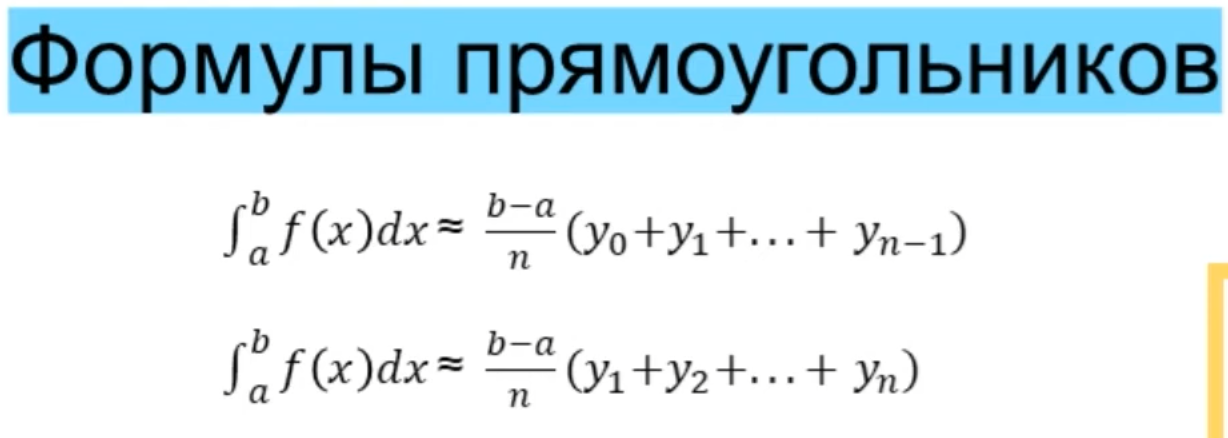
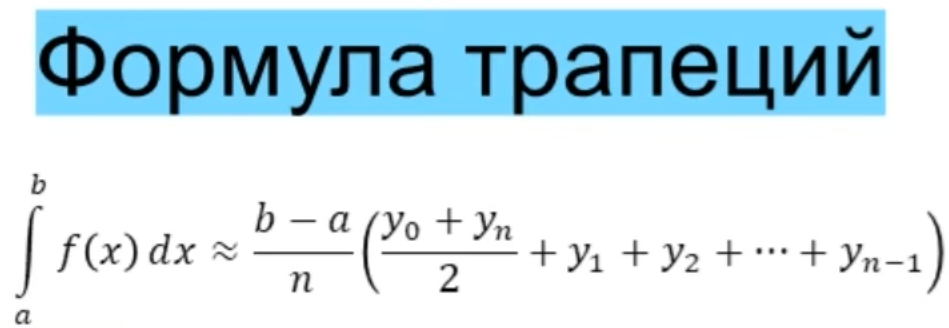
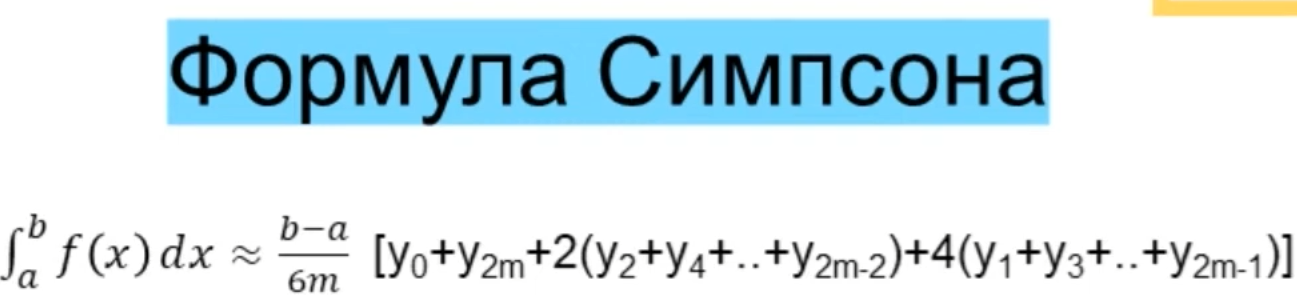
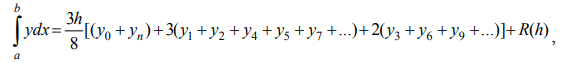
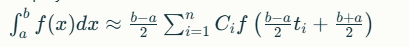
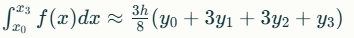

2. Вычислить значение интеграла $\int_{a}^{b} f(x)dx$ с заданной точностью ε, используя формулу трапеций или Симпсона, двумя способами:
- выбрать шаг интегрирования из оценки остаточного члена,
- использовать метод последовательного удвоения числа шагов.


In [4]:
# ======= ПАРАМЕТРЫ =======

a = 0.4
b = 1.2
epsilon = 1e-6  # Заданная точность

# ======= Ф-ЦИЯ =======

x_sym = sp.symbols('x')
f_expr = sp.cos(x_sym**2) * sp.sqrt(x_sym)
f = sp.lambdify(x_sym, f_expr, 'numpy')

# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * ((y[0] + y[-1])/2 + np.sum(y[1:-1]))

def simpson(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (h / 3) * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]))

# ======= ВЫЧИСЛЕНИЯ =======

f_diff2 = sp.diff(f_expr, x_sym, 2)
f_diff4 = sp.diff(f_expr, x_sym, 4)

f_diff2_func = sp.lambdify(x_sym, sp.Abs(f_diff2), 'numpy')
f_diff4_func = sp.lambdify(x_sym, sp.Abs(f_diff4), 'numpy')

x_vals = np.linspace(a, b, 5000)
M2 = np.max(f_diff2_func(x_vals))
M4 = np.max(f_diff4_func(x_vals))

print(f"M2: {M2:.4f} | M4: {M4:.4f}")

# ======= ОПИСАНИЕ ========

"""
Расписываем 2 метода

ВЫБОР ШАГА ИЗ ОЦЕНКИ ПОГРЕШНОСТИ - с использованием вычисления производных
Суть:
        Используем теоретическую формулу погрешности, чтобы ЗАРАНЕЕ 
        вычислить нужное n
Плюсы:
        Считаем интеграл только ОДИН раз
        Гарантируем нужную точность математически
Минусы:
        Нужно уметь вычислять производные высоких порядков
        Нужно находить их максимумы
        Оценка часто слишком завышена (n получается больше нужного)

ПОСЛЕДОВАТЕЛЬНОЕ УДВОЕНИЕ - без использования производных
Суть:   
        начинаем с грубого разбиения и постепенно уточняем, пока 
        погрешность не станет меньше ε
Плюсы:  
        НЕ нужны производные
        Автоматически адаптируется под сложность функции
        Дает РЕАЛЬНУЮ оценку погрешности (не завышенную)
Минусы: 
        Считаем интеграл несколько раз (но это быстро)
        Не знаем заранее, сколько итераций потребуется
"""

# ======= ВЫБОР ШАГА ИЗ ОЦЕНКИ ПОГРЕШНОСТИ =======

def calculate_n_from_error(a, b, epsilon, M, method='simpson'):
    """
    Вычисляет необходимое n из условия R_n < epsilon
    
    Для трапеций: R = (M2 * (b-a) * h^2) / 12
    Для Симпсона: R = (M4 * (b-a) * h^4) / 180
    """
    if method == 'trapezoid':
        # trapezoid
        # R = M2 * (b-a)^3 / (12*n^2) < epsilon
        # n^2 > M2 * (b-a)^3 / (12*epsilon)
        # n > (M2 * (b-a)^3 / (12*epsilon))**(1/2)
        n = np.ceil((M * (b - a)**3 / (12 * epsilon))**(1/2))
    else:  \
        # simpson
        # R = M4 * (b-a)^5 / (180*n^4) < epsilon
        # n^4 > M4 * (b-a)^5 / (180*epsilon)
        # n > (M4 * (b-a)^5 / (180*epsilon))**(1/4)
        n = np.ceil((M * (b - a)**5 / (180 * epsilon))**(1/4))
    
    # Для Симпсона n должно быть четным!!!
    if method == 'simpson' and n % 2 != 0:
        n += 1
    
    return int(n)
    pass

# ======= ПОСЛЕДОВАТЕЛЬНОЕ УДВОЕНИЕ =======

def adaptive_integration(f, a, b, epsilon, method='simpson'):
    """
    Метод последовательного удвоения числа шагов (Рунге)
    """
    n = 4 if method == 'simpson' else 2
    I_prev = None
    iterations = []
    
    while True:
        if method == 'simpson':
            I_current = simpson(f, a, b, n)
        else:
            I_current = trapezoid(f, a, b, n)
        
        iterations.append({'n': n, 'I': I_current})
        
        if I_prev is not None:
            # Правило Рунге: оценка погрешности
            if method == 'simpson':
                # Для Симпсона порядок точности p=4 => домнажаем 1/15
                error_estimate = abs(I_current - I_prev) / 15
            else:
                # Для трапеций порядок точности p=2 => домнажаем 1/3
                error_estimate = abs(I_current - I_prev) / 3
            
            if error_estimate < epsilon:
                return I_current, n, iterations, error_estimate
        
        I_prev = I_current
        n *= 2

# ======= ВЫВОД =======

print("\nВЫБОР ШАГА ИЗ ОЦЕНКИ ПОГРЕШНОСТИ")

# Симпсон
n_simp = calculate_n_from_error(a, b, epsilon, M4, 'simpson')
I_simp = simpson(f, a, b, n_simp)
print(f"\nМетод Симпсона:")
print(f"  Необходимое n = {n_simp}")
print(f"  Результат I = {I_simp:.10f}")

# Трапеции
n_trap = calculate_n_from_error(a, b, epsilon, M2, 'trapezoid')
I_trap = trapezoid(f, a, b, n_trap)
print(f"\nМетод трапеций:")
print(f"  Необходимое n = {n_trap}")
print(f"  Результат I = {I_trap:.10f}")

print("\nПОСЛЕДОВАТЕЛЬНОЕ УДВОЕНИЕ ШАГОВ")

# Симпсон
I_simp_adp, n_simp_adp, iter_simp, err_simp = adaptive_integration(f, a, b, epsilon, 'simpson')
print(f"\nМетод Симпсона:")
print(f"  Итерации:")
for it in iter_simp:
    print(f"    n = {it['n']:4d}, I = {it['I']:.10f}")
print(f"  Финальное n = {n_simp_adp}")
print(f"  Результат I = {I_simp_adp:.10f}")
print(f"  Оценка погрешности = {err_simp:.10f}")

# Трапеции
I_trap_adp, n_trap_adp, iter_trap, err_trap = adaptive_integration(f, a, b, epsilon, 'trapezoid')
print(f"\nМетод трапеций:")
print(f"  Итерации:")
for it in iter_trap:
    print(f"    n = {it['n']:4d}, I = {it['I']:.10f}")
print(f"  Финальное n = {n_trap_adp}")
print(f"  Результат I = {I_trap_adp:.10f}")
print(f"  Оценка погрешности = {err_trap:.10f}")


print("\n" + "="*60)
print(f"Точность ε = {epsilon:.2e}")
print("="*60)


M2: 5.8187 | M4: 100.4833

ВЫБОР ШАГА ИЗ ОЦЕНКИ ПОГРЕШНОСТИ

Метод Симпсона:
  Необходимое n = 22
  Результат I = 0.4841063833

Метод трапеций:
  Необходимое n = 499
  Результат I = 0.4841055737

ПОСЛЕДОВАТЕЛЬНОЕ УДВОЕНИЕ ШАГОВ

Метод Симпсона:
  Итерации:
    n =    4, I = 0.4842040904
    n =    8, I = 0.4841127467
    n =   16, I = 0.4841066770
  Финальное n = 16
  Результат I = 0.4841066770
  Оценка погрешности = 0.0000004046

Метод трапеций:
  Итерации:
    n =    2, I = 0.4404163765
    n =    4, I = 0.4732571619
    n =    8, I = 0.4813988505
    n =   16, I = 0.4834297204
    n =   32, I = 0.4839371511
    n =   64, I = 0.4840639908
    n =  128, I = 0.4840956996
    n =  256, I = 0.4841036268
    n =  512, I = 0.4841056086
  Финальное n = 512
  Результат I = 0.4841056086
  Оценка погрешности = 0.0000006606

Точность ε = 1.00e-06


Некторые вывод по этому заданию

По результатам можем сказать, что метод ССимпсона нанмого эффективней. Ведь ему понадобилось n = 16-22 разбиений,чтобы достигнуть точности ε = 10⁻⁶. Методу трапеций подобилось же 499-512 разбиений, что гораздо больше метода Симпсона.

Метод удвоения дает более оптимальное кол-во разбиений (n)
Метод Симпсона:
    С производными: n = 22
    Удвоение: n = 16
Метод трапеций:
    С производными: n = 499
    Удвоение: n = 512 (примерно одинаково)

